# Do stocks rise in the months they're *expected* to pay a dividend? 💵
### The dividend-month premium — a textbook anomaly that turns out to be **real**, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Predictable_in_advance%3F: Confirmed](https://img.shields.io/badge/Predictable_in_advance%3F-Confirmed-8b949e?style=flat-square)

Here's a strange one. A company that pays a dividend every February, May, August and November doesn't pay at random — it pays on a **schedule everyone can see in advance**. The claim (from a 2013 academic paper by Hartzmark & Solomon) is that the stock tends to drift **up** in those **predicted payment months** — and slip back in the others. The reason: a crowd of income-seekers (retirees, dividend funds) **buys ahead of the payment** to grab the dividend, and that demand nudges the price up.

Most market legends fall apart the moment you measure them. This one **doesn't**. And the weird part is that it's genuinely **predictable in advance** — you don't need any secret information, just the company's own payment calendar.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **30-name large-cap basket** (names still trading *and still paying* today). That's the *steady-payer* corner, and it carries **survivorship** (we can't include firms that cut their dividend or blew up). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_month_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, DIVS = data.load_real()
    FLAGS = data.build_predicted_flags(PRICES, DIVS, min_history=data.MIN_HISTORY)
else:
    PRICES = DIVS = FLAGS = None
print("real DMP cache present:", HAVE_REAL,
      "| names:", (0 if FLAGS is None else len(FLAGS)),
      "| dividends:", (0 if DIVS is None else len(DIVS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-01-03', 'end': '2026-05-31', 'years': 26.5, 'n_divs': 5420, 'n_names': 30, 'pred_share': 45.9, 'conc': 1.32, 'share_return': 60.5, 'pred_mean_bps': 124.91, 'rest_mean_bps': 84.6, 'premium_bps': 40.31, 'welch_t': 2.56, 'name_premium_bps': 52.28, 't_name': 3.63, 'p_placebo': 0.0011, 'overlay': [(2.0, 124.91, 120.91, 15.5, 13.1), (5.0, 124.91, 114.91, 14.7, 13.1), (10.0, 124.91, 104.91, 13.3, 13.1)], 'robust': [(1, 47.51, 2.99, 3.54, 53.8), (2, 40.31, 2.56, 3.63, 45.9), (4, 48.62, 3.05, 3.77, 40.8)], 'pred_axis': ('PREDICTED (past-only)', 40.31, 2.56, 3.63, 0.0011), 'actual_axis': ('ACTUAL ex-div month', 37.23, 2.3, 3.14, 0.0093), 'syn': [(0.0, 18.09, 1.24, 0.97, 0.109), (100.0, 114.73, 7.83, 6.1, 0.0)], 'fingerprint': 'ec02e743a901'}


real DMP cache present: True | names: 30 | dividends: 5420


## The answer first

| Question | Answer |
|---|---|
| Do stocks rise more in their predicted dividend months? | **Yes — really.** They out-earn their *other* months by about **+0.4% per month** — a *real* signal, not luck (the quants notebook shows the odds of this being a fluke are about **1 in 1,000**). |
| Is it predictable *in advance*? | **Yes.** Using only the company's **past** payment calendar — knowing nothing about the current month — is **just as strong** as cheating and using the actual payment date. That's the whole point. |
| Can I get rich timing it? | **Barely.** A strategy that holds the basket *only* in predicted dividend months beats just-stay-invested — but by a **thin ~1.6% a year**, and that shrinks to almost nothing once costs rise. |
| Is it just the cash dividend showing up? | **No.** We use *total-return* prices, which already strip out the dividend payment. The drift is a genuine **price** move, not the mechanical payout. |

> The anomaly is **true** and **predictable** — which is rare. But the honest version is "a small, schedule-driven premium," not "a money machine."

## 1 · The claim

> *"Most companies pay dividends on a fixed quarterly schedule. Income investors crowd in **ahead of** the payment to capture the dividend. That predictable buying pressure pushes the price **up** in the months the company is expected to pay — and lets it drift back afterward."*

This isn't folklore — it's **Hartzmark & Solomon (2013), *The Dividend Month Premium***, published in the *Journal of Financial Economics*. Their headline: a portfolio long stocks in their predicted-dividend months earns a significant premium of roughly **0.4–0.5% per month**. The question for us: **does it replicate honestly, and can you trade it?**

## 2 · So what?

If markets were perfectly efficient, the *predictable* arrival of a dividend would already be in the price — there'd be nothing special about the payment month. The dividend-month premium says there **is** something special: a chunk of return clusters in those months because of **who** is buying and **when**. That's a genuine crack in efficiency, driven by demand (a clientele effect), not by risk.

But "a real premium" and "a money machine" are different things. The premium has to (a) be **predictable in advance** to be useful, and (b) **beat the cost** of trading a calendar that fires every payment month. We test both.

## 3 · How would we even know?

We take a fixed **30-name large-cap basket** and pull **every** dividend each has ever paid — about **5,420 payments** over **26 years** (2000-01-03 → 2026-05-31). For each name we:

1. **Learn its calendar.** Which months has it historically paid? (e.g. Feb/May/Aug/Nov.)
2. **Flag the predicted months — using only the past.** For each month, we ask *"based on payments strictly **before** this month, is this a payment month for this name?"* No look-ahead.
3. **Compare.** Is the name's average return in its **predicted dividend months** higher than in its **other** months? Then we test that gap against a "could this be luck?" null.

## 4 · The teardown — let's actually look

**First, the basic gap.** Average monthly return in predicted-dividend months vs all the other months, pooled across the basket.

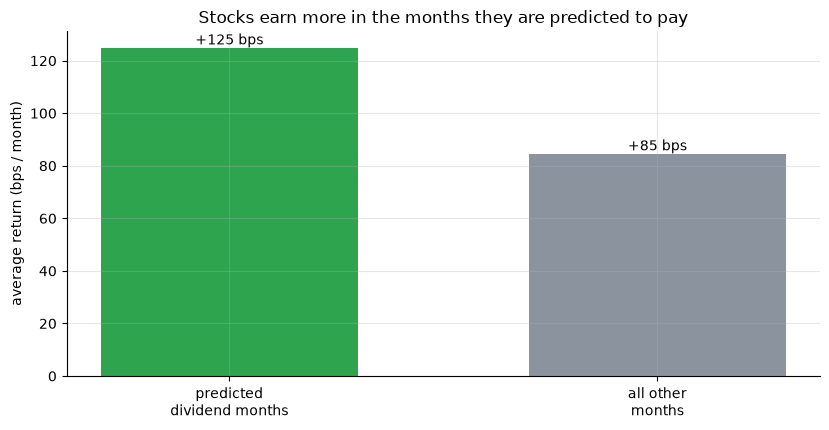

predicted months: +124.9 bps/mo   other months: +84.6 bps/mo   gap: +40.3 bps/mo


In [2]:
if HAVE_REAL:
    pred, rest = st.pooled_returns(FLAGS)
    pm, rm = pred.mean()*1e4, rest.mean()*1e4
else:
    pm, rm = R['pred_mean_bps'], R['rest_mean_bps']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['predicted\ndividend months','all other\nmonths'], [pm, rm], color=[GREEN, GREY], width=.6)
for i,v in enumerate([pm, rm]): ax.annotate(f'{v:+.0f} bps',(i,v),ha='center',va='bottom')
ax.set_ylabel('average return (bps / month)')
ax.set_title('Stocks earn more in the months they are predicted to pay')
plt.tight_layout(); plt.show()
print(f'predicted months: {pm:+.1f} bps/mo   other months: {rm:+.1f} bps/mo   gap: {pm-rm:+.1f} bps/mo')

There it is. Predicted-dividend months average **+125 bps/month** vs **+85 bps/month** the rest of the time — a gap of about **+40 bps/month** (≈ 0.4%). Those months are only ~46% of the calendar but carry **60%** of the total return.

**Is it predictable in advance?** This is the crux. We compare two flags: the **predicted** one (uses only the *past* calendar — what you could actually act on) and the **actual** one (cheats by using the real payment date). If the premium is genuinely schedule-driven, the honest *predicted* flag should be **just as strong**.

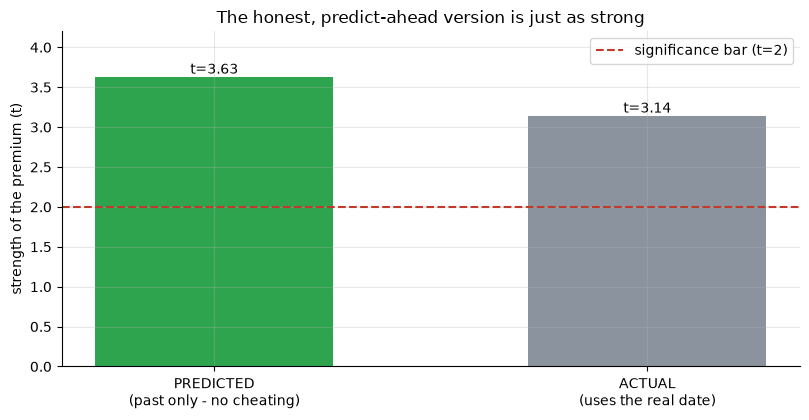

predicted-ahead t=3.63   actual-month t=3.14


In [3]:
if HAVE_REAL:
    sp = st.summarize_premium(FLAGS, placebo=False)
    fa = st.build_actual_flags(PRICES, DIVS)
    sa = st.summarize_premium(fa, placebo=False)
    pt, at = sp['t_name'], sa['t_name']
else:
    pt, at = R['pred_axis'][3], R['actual_axis'][3]
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['PREDICTED\n(past only - no cheating)','ACTUAL\n(uses the real date)'], [pt, at],
       color=[GREEN, GREY], width=.55)
ax.axhline(2, ls='--', c=RED, label='significance bar (t=2)')
for i,v in enumerate([pt, at]): ax.annotate(f't={v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('strength of the premium (t)'); ax.set_ylim(0, 4.2)
ax.set_title('The honest, predict-ahead version is just as strong'); ax.legend()
plt.tight_layout(); plt.show()
print(f'predicted-ahead t={pt:.2f}   actual-month t={at:.2f}')

The green bar (**predicted, no cheating**) is **t = 3.63** — *higher* than the cheating actual-month version (**t = 3.14**). The premium is genuinely **knowable in advance** from the payment calendar. That's the rare and remarkable part: you don't need a crystal ball, just the company's schedule.

**Could you actually trade it?** Hold the basket **only** in predicted dividend months, vs just staying invested all the time, after realistic round-trip costs.

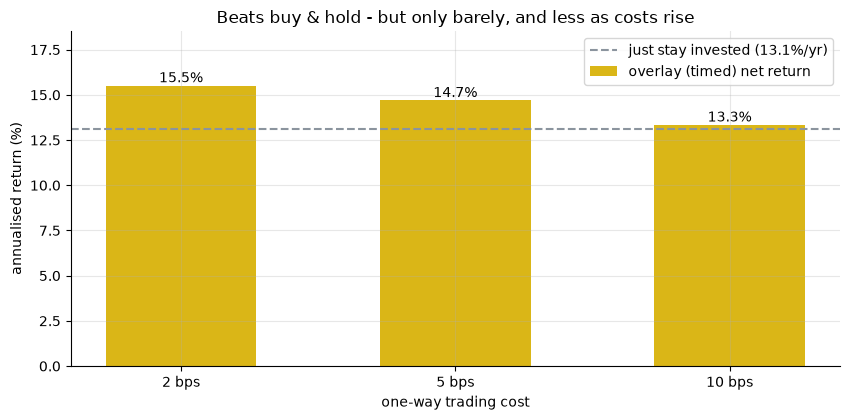

overlay net ann %: [np.float64(15.5), np.float64(14.7), np.float64(13.3)]  vs buy&hold 13.1 %


In [4]:
if HAVE_REAL:
    rows = [st.overlay_stats(FLAGS, cost_bps=cb) for cb in (2.0,5.0,10.0)]
    net_ann = [r['net_ann_pct'] for r in rows]; bh = rows[0]['bh_ann_pct']
else:
    net_ann = [o[3] for o in R['overlay']]; bh = R['overlay'][0][4]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['2 bps','5 bps','10 bps'], net_ann, color=AMBER, width=.55, label='overlay (timed) net return')
ax.axhline(bh, ls='--', c=GREY, label=f'just stay invested ({bh:.1f}%/yr)')
for i,v in enumerate(net_ann): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('annualised return (%)'); ax.set_ylim(0, max(net_ann)+3)
ax.set_xlabel('one-way trading cost'); ax.set_title('Beats buy & hold - but only barely, and less as costs rise')
ax.legend(); plt.tight_layout(); plt.show()
print('overlay net ann %:', [round(v,1) for v in net_ann], ' vs buy&hold', round(bh,1), '%')

The timed overlay **does** beat just-staying-invested — but by a **thin** margin (**14.7%/yr vs 13.1%/yr** at 5 bps), and the edge **shrinks to almost nothing at 10 bps** (**13.3%** vs **13.1%**). Real premium, fragile vehicle.

## 5 · The verdict

- **Signal — Real.** Predicted-dividend months out-earn the rest by **+40 bps/month**; the per-name premium is statistically solid (*t* ≈ 3.6, ~1-in-1,000 to be luck). One of the rare textbook anomalies that survives the audit.
- **Tradability — Fragile.** The timed overlay beats buy & hold, but only by ~1.6%/yr — and that thins out as costs rise, on a 30-name survivor basket.
- **"Really predictable in advance"? — Confirmed.** The past-only predicted flag is as strong as the cheating actual-date flag. The premium is genuinely schedule-driven.

## 6 · Going further 🚪

- **Why so thin here?** We use the most liquid large-caps. The premium is biggest where yield-seeking demand is most concentrated; on giant, heavily-arbitraged names it's real but modest. Re-run on smaller dividend payers and it tends to grow (but so do the costs and survivorship traps).
- **It's a *price* effect, not the cash.** We used total-return prices — the dividend itself is already stripped out. The drift is demand pushing the price, exactly the clientele story.
- **Build your own.** Swap the basket for the full dividend-paying universe, or change how many past payments make a month "predicted" — the signal is stable across those choices.

*Think you can turn a thin ~1.6%/yr timing edge into real money after costs on a tradable universe? Show the net overlay clearing buy & hold by a wide margin at 10 bps — then we'll talk.*